In [ ]:
import marimo as mo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


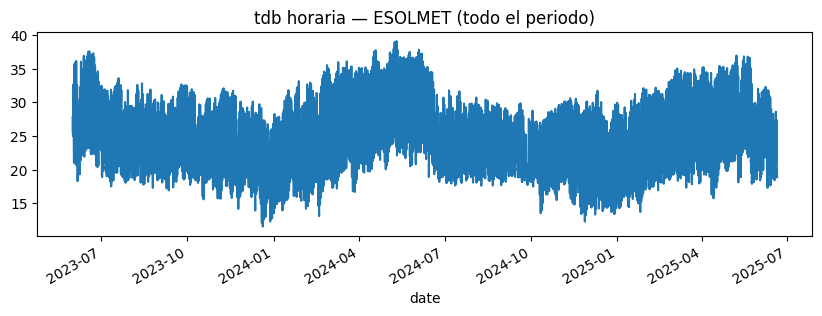

In [ ]:
f = 'data/ClimaLab_2023-05-31_2025-06-20.parquet'
tdb_all = pd.read_parquet(f)['tdb']
tdb_h = tdb_all.resample('h').mean().dropna()
tdb_h.plot(figsize=(10, 3), title='tdb horaria — ESOLMET (todo el periodo)')

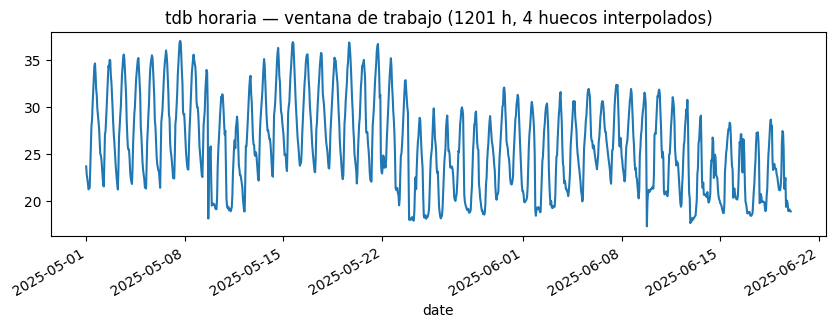

In [ ]:
tdb = tdb_h.loc['2025-05-01':'2025-06-20']
y = tdb.astype(float).asfreq('h').interpolate('time')
gaps = int(tdb.asfreq('h').isna().sum())
tdb.plot(figsize=(10, 3), title=f'tdb horaria — ventana de trabajo ({len(y)} h, {gaps} huecos interpolados)')

In [ ]:
horizon = 240
y_train = y.iloc[:-horizon]
y_test = y.iloc[-horizon:]
mo.md(
    f"Train: **{len(y_train)}** h ({y_train.index[0]} → {y_train.index[-1]})  \n"
    f"Test:  **{len(y_test)}** h ({y_test.index[0]} → {y_test.index[-1]})"
)

Train: **961** h (2025-05-01 00:00:00 → 2025-06-10 00:00:00)  
Test:  **240** h (2025-06-10 01:00:00 → 2025-06-20 00:00:00)

In [ ]:
order_form = (
    mo.md(
        """
        **Non-seasonal**  p = {p}, d = {d}, q = {q}

        **Seasonal**      P = {P}, D = {D}, Q = {Q}, s = {s}
        """
    )
    .batch(
        p=mo.ui.slider(0, 5, value=2, label="p"),
        d=mo.ui.slider(0, 2, value=0, label="d"),
        q=mo.ui.slider(0, 5, value=1, label="q"),
        P=mo.ui.slider(0, 2, value=1, label="P"),
        D=mo.ui.slider(0, 1, value=1, label="D"),
        Q=mo.ui.slider(0, 2, value=1, label="Q"),
        s=mo.ui.number(2, 168, value=24, label="s"),
    )
    .form(submit_button_label="Fit SARIMA")
)
order_form

&lt;marimo-form data-initial-value=&#x27;null&#x27; data-label=&#x27;null&#x27; data-element-id=&#x27;&amp;quot;lEQa-22&amp;quot;&#x27; data-loading=&#x27;false&#x27; data-bordered=&#x27;true&#x27; data-submit-button-label=&#x27;&amp;quot;Fit SARIMA&amp;quot;&#x27; data-submit-button-disabled=&#x27;false&#x27; data-clear-on-submit=&#x27;false&#x27; data-show-clear-button=&#x27;false&#x27; data-clear-button-label=&#x27;&amp;quot;Clear&amp;quot;&#x27; data-should-validate=&#x27;false&#x27;&gt;&lt;marimo-ui-element object-id=&#x27;lEQa-22&#x27; random-id=&#x27;b975807e-a879-0eec-6ee3-88489ac17056&#x27;&gt;&lt;marimo-dict data-initial-value=&#x27;{&amp;quot;p&amp;quot;:2,&amp;quot;d&amp;quot;:0,&amp;quot;q&amp;quot;:1,&amp;quot;P&amp;quot;:1,&amp;quot;D&amp;quot;:1,&amp;quot;Q&amp;quot;:1,&amp;quot;s&amp;quot;:24}&#x27; data-label=&#x27;null&#x27; data-element-ids=&#x27;{&amp;quot;lEQa-15&amp;quot;:&amp;quot;p&amp;quot;,&amp;quot;lEQa-16&amp;quot;:&amp;quot;d&amp;quot;,&amp;quot;lEQa-17&amp;quot;:&amp;quot;q&amp;quot;,&amp;quot;lEQa-18&amp;quot;:&amp;quot;P&amp;quot;,&amp;quot;lEQa-19&amp;quot;:&amp;quot;D&amp;quot;,&amp;quot;lEQa-20&amp;quot;:&amp;quot;Q&amp;quot;,&amp;quot;lEQa-21&amp;quot;:&amp;quot;s&amp;quot;}&#x27;&gt;&lt;span class=&quot;markdown prose dark:prose-invert contents&quot;&gt;&lt;span class=&quot;paragraph&quot;&gt;&lt;strong&gt;Non-seasonal&lt;/strong&gt;  p = &lt;marimo-ui-element object-id=&#x27;lEQa-15&#x27; random-id=&#x27;6f82d0b9-db6e-4089-32a9-2501dc18acd2&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;2&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;p&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;5&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, d = &lt;marimo-ui-element object-id=&#x27;lEQa-16&#x27; random-id=&#x27;8e35956e-1691-f360-3863-01111cfb6c69&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;0&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;d&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;2&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, q = &lt;marimo-ui-element object-id=&#x27;lEQa-17&#x27; random-id=&#x27;8fa5569a-3a6c-ffd0-abbe-9be02830e1d1&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;q&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;5&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;&lt;/span&gt;
&lt;span class=&quot;paragraph&quot;&gt;&lt;strong&gt;Seasonal&lt;/strong&gt;      P = &lt;marimo-ui-element object-id=&#x27;lEQa-18&#x27; random-id=&#x27;96f000fe-b9f1-f7d4-3385-40a7a32c8f1c&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;P&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;2&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, D = &lt;marimo-ui-element object-id=&#x27;lEQa-19&#x27; random-id=&#x27;c725745f-ae7b-daad-2d18-8ed2cde297c2&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;D&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;1&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, Q = &lt;marimo-ui-element object-id=&#x27;lEQa-20&#x27; random-id=&#x27;749f7f42-4b88-aae6-bfd5-e7d82986a729&#x27;&gt;&lt;marimo-slider data-initial-value=&#x27;1&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;Q&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;0&#x27; data-stop=&#x27;2&#x27; data-steps=&#x27;[]&#x27; data-debounce=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27; data-show-value=&#x27;false&#x27; data-include-input=&#x27;false&#x27; data-full-width=&#x27;false&#x27;&gt;&lt;/marimo-slider&gt;&lt;/marimo-ui-element&gt;, s = &lt;marimo-ui-element object-id=&#x27;lEQa-21&#x27; random-id=&#x27;0db64585-b1a4-f0f7-4441-acf4faee2d17&#x27;&gt;&lt;marimo-number data-initial-value=&#x27;24&#x27; data-label=&#x27;&amp;quot;&amp;lt;span class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;gt;&amp;lt;span class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;gt;s&amp;lt;/span&amp;gt;&amp;lt;/span&amp;gt;&amp;quot;&#x27; data-start=&#x27;2&#x27; data-stop=&#x27;168&#x27; data-debounce=&#x27;false&#x27; data-full-width=&#x27;false&#x27; data-disabled=&#x27;false&#x27;&gt;&lt;/marimo-number&gt;&lt;/marimo-ui-element&gt;&lt;/span&gt;&lt;/span&gt;&lt;/marimo-dict&gt;&lt;/marimo-ui-element&gt;&lt;/marimo-form&gt;

In [ ]:
cfg = order_form.value
mo.stop(cfg is None, mo.md("Pick orders above and click **Fit SARIMA**."))

order = (cfg["p"], cfg["d"], cfg["q"])
seasonal_order = (cfg["P"], cfg["D"], cfg["Q"], cfg["s"])

with mo.status.spinner("Fitting SARIMA..."):
    res = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

fc = res.get_forecast(steps=len(y_test))
y_hat = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)

burn = max(seasonal_order[3], 24)
resid = res.resid.iloc[burn:]

fig, axes = plt.subplots(4, 1, figsize=(11, 12))

ax = axes[0]
y_train.iloc[-7 * 24:].plot(ax=ax, label="train (last 7 d)")
y_test.plot(ax=ax, label="test", color="black")
y_hat.plot(ax=ax, label="forecast", color="red")
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="red", alpha=0.15)
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Forecast vs holdout")
ax.set_ylabel("tdb (°C)")

ax = axes[1]
resid.plot(ax=ax)
ax.set_title("Residuals (after burn-in)")
ax.axhline(0, color="k", lw=0.5)

plot_acf(resid, ax=axes[2], lags=48)
plot_pacf(resid, ax=axes[3], lags=48, method="ywm")

plt.tight_layout()

rmse = float(np.sqrt(((y_test - y_hat) ** 2).mean()))
mae = float((y_test - y_hat).abs().mean())

mo.vstack([
    mo.md(
        f"**SARIMA{order} x {seasonal_order}** &nbsp;·&nbsp; "
        f"AIC = `{res.aic:.2f}` &nbsp;·&nbsp; BIC = `{res.bic:.2f}` &nbsp;·&nbsp; "
        f"RMSE(test) = `{rmse:.2f} °C` &nbsp;·&nbsp; MAE(test) = `{mae:.2f} °C`"
    ),
    fig,
    mo.accordion({"Full summary": mo.md(f"```\n{res.summary().as_text()}\n```")}),
])

Pick orders above and click **Fit SARIMA**.